# 05 — Tour of the 8 Analysis Types

A whirlwind tour. We submit all eight analyses in one batched
`run_area_and_wait` call, sharing the buildings / vegetation / weather
inputs across all of them.

| Analysis                       | Payload class                | Needs                                  |
|--------------------------------|------------------------------|----------------------------------------|
| Wind speed                     | `WindModelRequest`           | wind_speed, wind_direction             |
| Pedestrian wind comfort        | `PwcModelRequest`            | criteria, wind_speed[], wind_direction[] |
| Daylight availability          | `SolarModelRequest`          | location, time_period                  |
| Direct sun hours               | `SolarModelRequest`          | location, time_period                  |
| Sky view factors               | `SvfModelRequest`            | location                               |
| Solar radiation                | `SolarRadiationModelRequest` | location, time_period, weather         |
| Thermal comfort index (UTCI)   | `UtciModelRequest`           | location, time_period, weather         |
| Thermal comfort statistics (TCS)| `TcsModelRequest`           | location, time_period, weather, subtype |

In [1]:
from dotenv import load_dotenv

load_dotenv()

import logging
import numpy as np
import matplotlib.pyplot as plt

from infrared_sdk import AreaResult, InfraredClient
from infrared_sdk.analyses.types import (
    AnalysesName,
    BaseAnalysisPayload,
    PwcCriteria,
    PwcModelRequest,
    SolarModelRequest,
    SolarRadiationModelRequest,
    SvfModelRequest,
    TcsModelBaseRequest,
    TcsModelRequest,
    TcsSubtype,
    UtciModelBaseRequest,
    UtciModelRequest,
    WindModelRequest,
)
from infrared_sdk.models import Location, TimePeriod, extract_weather_fields
from cities import get

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s  %(levelname)-7s  %(message)s"
)
logging.getLogger("infrared_sdk").setLevel(logging.WARNING)

city = get("munich")
print(f"Running over: {city.name}")

Running over: Munich


## Pull layers and weather once

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)
    veg = client.vegetation.get_area(city.polygon_small)
    gm = client.ground_materials.get_area(city.polygon_small)

    stations = client.weather.get_weather_file_from_location(
        lat=city.latitude,
        lon=city.longitude,
        radius=50,
    )
    weather_id = stations[0].get("identifier") or stations[0].get("uuid")

    # Single-month window: daylight-availability and direct-sun-hours
    # only support a single month, so we keep the demo aligned with that.
    tp = TimePeriod(
        start_month=7, start_day=1, start_hour=6, end_month=7, end_day=31, end_hour=20
    )
    weather = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)

print(
    f"buildings={area.total_buildings}  trees={veg.total_trees}  "
    f"ground_features={gm.total_features}  weather_points={len(weather)}"
)

buildings=340  trees=119  ground_features=25  weather_points=465


## Build payloads

All eight payloads go into one flat list. The SDK pools every
`(payload x tile)` job submission into a single thread pool, so analyses
run concurrently rather than sequentially. Layer inputs (buildings,
vegetation, ground materials) are shared across every payload.

In [3]:
location = Location(latitude=city.latitude, longitude=city.longitude)
wind_fields = extract_weather_fields(weather, ["windSpeed", "windDirection"])

# All 8 payloads go into one list. The SDK pools every (payload x tile)
# job into a single thread pool, so analyses run concurrently.
payloads = [
    WindModelRequest(
        analysis_type=AnalysesName.wind_speed, wind_speed=5, wind_direction=270
    ),
    SvfModelRequest(
        analysis_type=AnalysesName.sky_view_factors,
        latitude=city.latitude,
        longitude=city.longitude,
    ),
    PwcModelRequest(
        analysis_type=AnalysesName.pedestrian_wind_comfort,
        criteria=PwcCriteria.lawson_lddc,
        wind_speed=wind_fields["wind_speed"],
        wind_direction=wind_fields["wind_direction"],
    ),
    SolarModelRequest(
        analysis_type=AnalysesName.daylight_availability,
        latitude=city.latitude,
        longitude=city.longitude,
        time_period=tp,
    ),
    SolarModelRequest(
        analysis_type=AnalysesName.direct_sun_hours,
        latitude=city.latitude,
        longitude=city.longitude,
        time_period=tp,
    ),
    SolarRadiationModelRequest.from_weatherfile_payload(
        payload=BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation),
        location=location,
        time_period=tp,
        weather_data=weather,
    ),
    UtciModelRequest.from_weatherfile_payload(
        payload=UtciModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_index),
        location=location,
        time_period=tp,
        weather_data=weather,
    ),
    TcsModelRequest.from_weatherfile_payload(
        payload=TcsModelBaseRequest(
            analysis_type=AnalysesName.thermal_comfort_statistics,
            subtype=TcsSubtype.heat_stress,
        ),
        location=location,
        time_period=tp,
        weather_data=weather,
    ),
]
print(f"{len(payloads)} payloads queued for one batched run")

8 payloads queued for one batched run


## Submit and wait

> **Note.** This demo runs on `polygon_small` (single tile). On the
> testing backend a few of the heavier analyses (solar-radiation, UTCI,
> TCS) can occasionally come back as `0/1` for sparse polygons. The
> rendering cell below skips empty results gracefully.

In [4]:
import time

results: dict[str, AreaResult] = {}

t0 = time.monotonic()
with InfraredClient() as client:
    rs = client.run_area_and_wait(
        payloads,
        city.polygon_small,
        buildings=area.buildings,
        vegetation=veg.features,
        ground_materials=gm.layers,
    )
for r in rs:
    results[r.analysis_type] = r

print(f"All {len(rs)} analyses finished in {time.monotonic() - t0:.1f}s")
for r in rs:
    print(f"  {r.analysis_type:35s}  {r.succeeded_jobs}/{r.total_jobs} jobs")

All 8 analyses finished in 35.0s
  wind-speed                           1/1 jobs
  sky-view-factors                     1/1 jobs
  pedestrian-wind-comfort              1/1 jobs
  daylight-availability                1/1 jobs
  direct-sun-hours                     1/1 jobs
  solar-radiation                      1/1 jobs
  thermal-comfort-index                1/1 jobs
  thermal-comfort-statistics           1/1 jobs


## Render every result in one figure

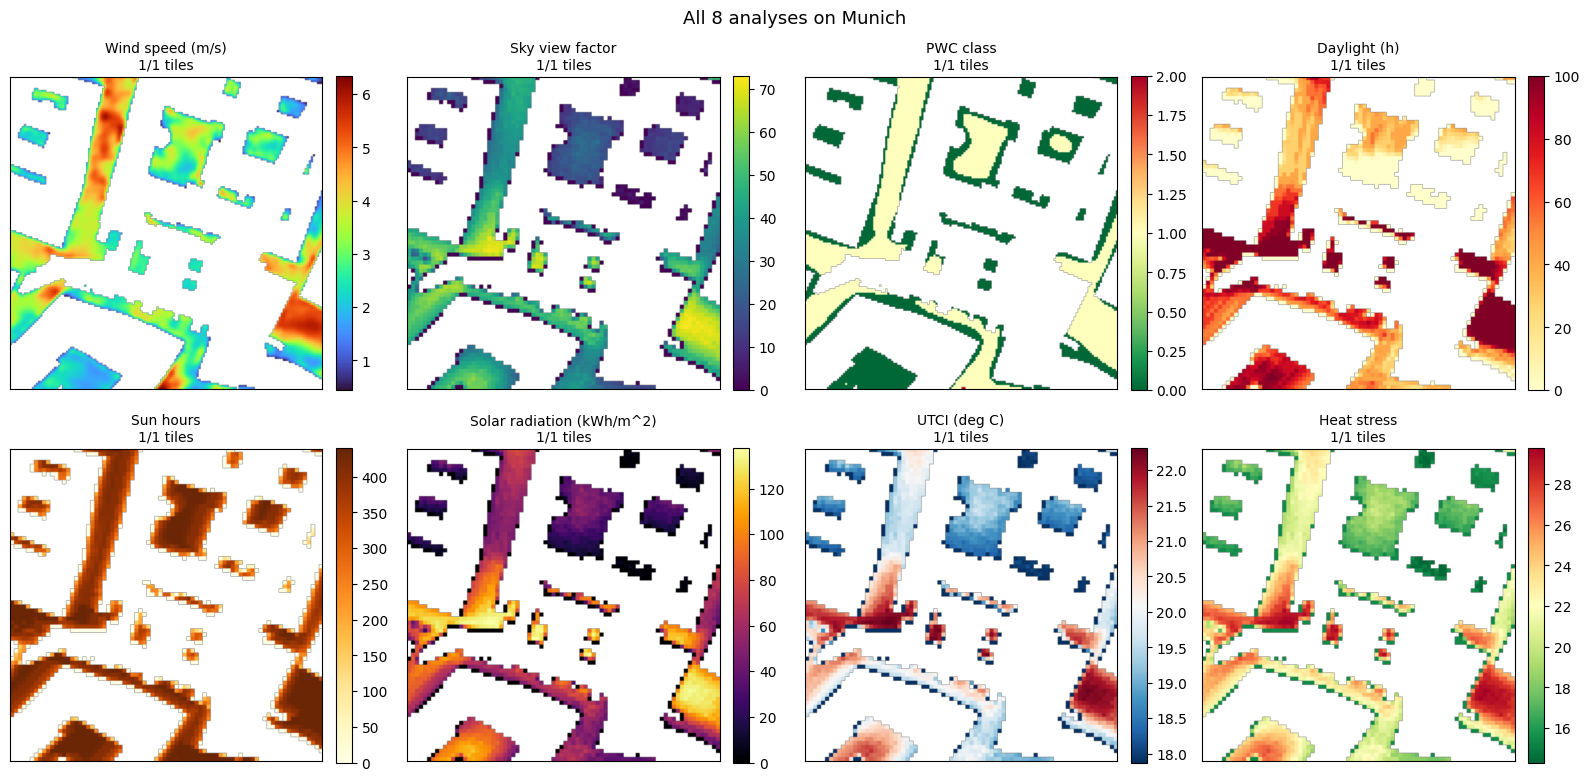

In [5]:
ORDER = [
    AnalysesName.wind_speed,
    AnalysesName.sky_view_factors,
    AnalysesName.pedestrian_wind_comfort,
    AnalysesName.daylight_availability,
    AnalysesName.direct_sun_hours,
    AnalysesName.solar_radiation,
    AnalysesName.thermal_comfort_index,
    AnalysesName.thermal_comfort_statistics,
]
LABELS = {
    AnalysesName.wind_speed: ("Wind speed (m/s)", "turbo"),
    AnalysesName.sky_view_factors: ("Sky view factor", "viridis"),
    AnalysesName.pedestrian_wind_comfort: ("PWC class", "RdYlGn_r"),
    AnalysesName.daylight_availability: ("Daylight (h)", "YlOrRd"),
    AnalysesName.direct_sun_hours: ("Sun hours", "YlOrBr"),
    AnalysesName.solar_radiation: ("Solar radiation (kWh/m^2)", "inferno"),
    AnalysesName.thermal_comfort_index: ("UTCI (deg C)", "RdBu_r"),
    AnalysesName.thermal_comfort_statistics: ("Heat stress", "RdYlGn_r"),
}


def crop_to_data(g):
    """Trim NaN borders. Returns None when the grid has no valid cells."""
    if g.size == 0:
        return None
    mask = ~np.isnan(g)
    if not mask.any():
        return None
    ys, xs = np.where(mask)
    return g[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]


NEWLINE = chr(10)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, atype in enumerate(ORDER):
    ax = axes.flat[i]
    title, cmap = LABELS[atype]
    r = results.get(atype)
    if r is None:
        ax.text(
            0.5,
            0.5,
            title + NEWLINE + "(no result)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=10,
            color="#888",
        )
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    cropped = crop_to_data(r.merged_grid)
    if cropped is None:
        ax.text(
            0.5,
            0.5,
            title + NEWLINE + f"(no data, {r.succeeded_jobs}/{r.total_jobs})",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=10,
            color="#888",
        )
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    im = ax.imshow(np.flipud(cropped), cmap=cmap, vmin=r.min_legend, vmax=r.max_legend)
    ax.set_title(
        title + NEWLINE + f"{r.succeeded_jobs}/{r.total_jobs} tiles", fontsize=10
    )
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"All 8 analyses on {city.name}", fontsize=13)
plt.tight_layout()
plt.show()

## Print the per-analysis stats

In [6]:
for atype in ORDER:
    r = results.get(atype)
    if not r:
        print(f"{str(atype):35s}  (missing)")
        continue
    g = r.merged_grid
    valid = g[~np.isnan(g)]
    if valid.size == 0:
        print(
            f"{str(atype):35s}  shape={g.shape}  jobs={r.succeeded_jobs}/{r.total_jobs}  "
            f"(no valid cells)"
        )
        continue
    print(
        f"{str(atype):35s}  shape={g.shape}  jobs={r.succeeded_jobs}/{r.total_jobs}  "
        f"min={float(valid.min()):7.2f}  median={float(np.median(valid)):7.2f}  "
        f"max={float(valid.max()):7.2f}"
    )

wind-speed                           shape=(256, 256)  jobs=1/1  min=   0.44  median=   3.13  max=   6.34
sky-view-factors                     shape=(256, 256)  jobs=1/1  min=   0.00  median=  36.47  max=  73.06
pedestrian-wind-comfort              shape=(256, 256)  jobs=1/1  min=   0.00  median=   1.00  max=   2.00
daylight-availability                shape=(256, 256)  jobs=1/1  min=   0.00  median=  41.06  max= 100.00
direct-sun-hours                     shape=(256, 256)  jobs=1/1  min=   0.00  median= 372.00  max= 440.00
solar-radiation                      shape=(256, 256)  jobs=1/1  min=   0.00  median=  56.41  max= 137.75
thermal-comfort-index                shape=(256, 256)  jobs=1/1  min=  17.88  median=  19.75  max=  22.31
thermal-comfort-statistics           shape=(256, 256)  jobs=1/1  min=  14.31  median=  21.39  max=  29.77


That's the full SDK analysis surface. Next: `06_image_rendering.ipynb`
covers PNG generation via the SDK itself (no plotly/matplotlib needed).